# IPF simulated reference robustness summary


## Benchmark reference robustness

Saved table: /Path/to/output/simulation_IPF/reference_robustness_nested_matrix_celltype_ccc.csv
Saved table: /Path/to/output/simulation_IPF/reference_robustness_nested_matrix_summary.csv
Directed combinations: 20
Available methods: 10
Using publication font: DejaVu Sans


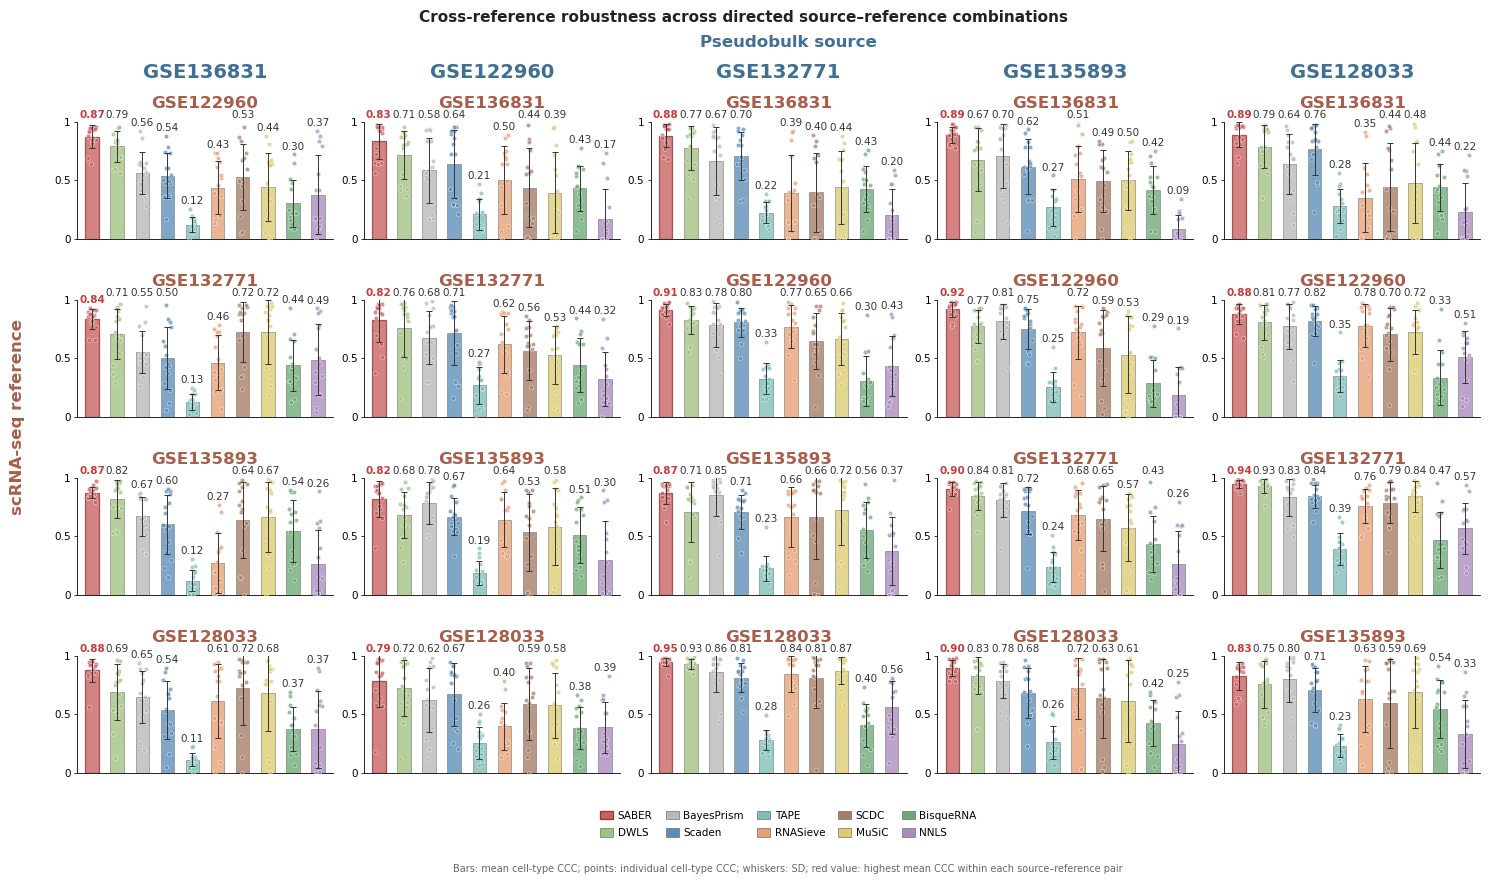

Saved: /Path/to/output/simulation_IPF/reference_robustness_compact_nested_matrix.pdf
Saved: /Path/to/output/simulation_IPF/reference_robustness_compact_nested_matrix.png


,Combo,Reference,Source,Method,MethodDisplay,MeanCCC,MedianCCC,SD,SEM,MinCCC,MaxCCC,NCellTypes
0,crossdataset_ref1_bulk2,IPFREF1,IPFREF2,BayesPrism,BayesPrism,0.584216,0.574218,0.275123,0.071036,0.164789,0.940839,15
1,crossdataset_ref1_bulk2,IPFREF1,IPFREF2,BisqueRNA,BisqueRNA,0.430756,0.445418,0.192768,0.049772,0.066818,0.773626,15
2,crossdataset_ref1_bulk2,IPFREF1,IPFREF2,DWLS,DWLS,0.713560,0.801538,0.207869,0.053672,0.366225,0.955223,15
3,crossdataset_ref1_bulk2,IPFREF1,IPFREF2,MuSiC,MuSiC,0.392092,0.249289,0.344651,0.088989,0.000000,0.950104,15
4,crossdataset_ref1_bulk2,IPFREF1,IPFREF2,NNLS,NNLS,0.171158,0.045107,0.254286,0.065656,0.000000,0.731520,15
...,...,...,...,...,...,...,...,...,...,...,...,...
195,crossdataset_ref5_bulk4,IPFREF5,IPFREF4,RNASieve,RNASieve,0.720674,0.839682,0.257563,0.066502,0.030198,0.975868,15
196,crossdataset_ref5_bulk4,IPFREF5,IPFREF4,SABER,SABER,0.896126,0.914944,0.069696,0.017995,0.782211,0.979951,15
197,crossdataset_ref5_bulk4,IPFREF5,IPFREF4,SCDC,SCDC,0.634625,0.663412,0.335234,0.086557,0.015637,0.973634,15
198,crossdataset_ref5_bulk4,IPFREF5,IPFREF4,Scadenpytorch,Scaden,0.683018,0.700300,0.211228,0.054539,0.232425,0.966594,15


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.patches import Patch

# Configuration and output paths
REFERENCE_DATA_ROOT = "/Path/to/simulation_IPF/data"
MANIFEST_PATH = os.path.join(REFERENCE_DATA_ROOT, "crossdataset_manifest.csv")
REFERENCE_METHODS = [
    "SABER",
    "DWLS",
    "BayesPrism",
    "Scadenpytorch",
    "TAPE",
    "RNASieve",
    "SCDC",
    "MuSiC",
    "BisqueRNA",
    "NNLS",
]
METHOD_DISPLAY = {
    "SABER": "SABER",
    "Scadenpytorch": "Scaden",
    "BisqueRNA": "BisqueRNA",
    "RNASieve": "RNASieve",
    "NNLS": "NNLS",
    "TAPE": "TAPE",
    "MuSiC": "MuSiC",
    "SCDC": "SCDC",
    "BayesPrism": "BayesPrism",
    "DWLS": "DWLS",
}
METHOD_PALETTE = {
    "SABER": "#C95F5F",
    "Scadenpytorch": "#5B8DB8",
    "BisqueRNA": "#6BAA75",
    "RNASieve": "#E69F73",
    "NNLS": "#A98BBE",
    "TAPE": "#7DBDB8",
    "MuSiC": "#DCCB70",
    "SCDC": "#A67C64",
    "BayesPrism": "#B8B8B8",
    "DWLS": "#A1C181",
}
DATASET_DISPLAY = {
    "IPFREF1": "GSE136831",
    "IPFREF2": "GSE122960",
    "IPFREF3": "GSE132771",
    "IPFREF4": "GSE135893",
    "IPFREF5": "GSE128033",
}
OUTPUT_DIR = "/Path/to/output/simulation_IPF"
os.makedirs(OUTPUT_DIR, exist_ok=True)
OUTPUT_PDF = os.path.join(OUTPUT_DIR, "reference_robustness_compact_nested_matrix.pdf")
OUTPUT_PNG = os.path.join(OUTPUT_DIR, "reference_robustness_compact_nested_matrix.png")
OUTPUT_RAW_TABLE = os.path.join(OUTPUT_DIR, "reference_robustness_nested_matrix_celltype_ccc.csv")
OUTPUT_SUMMARY_TABLE = os.path.join(OUTPUT_DIR, "reference_robustness_nested_matrix_summary.csv")
SHOW_ERROR_BARS = True
SOURCE_LABEL_COLOR = "#3F6F92"
REFERENCE_LABEL_COLOR = "#A85E4A"
TICK_FONT_SIZE = 7.5
GLOBAL_AXIS_FONT_SIZE = 12.0
LEGEND_FONT_SIZE = 7.5
Y_MIN = 0.0
Y_MAX = 1.0
STRIP_JITTER = 0.16


# CCC statistics and input validation
def calculate_ccc(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    valid = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[valid]
    y_pred = y_pred[valid]
    if len(y_true) < 2:
        return np.nan
    mean_true = np.mean(y_true)
    mean_pred = np.mean(y_pred)
    var_true = np.var(y_true, ddof=1)
    var_pred = np.var(y_pred, ddof=1)
    covariance = np.cov(y_true, y_pred, ddof=1)[0, 1]
    denominator = var_true + var_pred + (mean_true - mean_pred) ** 2
    if denominator == 0:
        return np.nan
    return 2 * covariance / denominator


def load_manifest():
    if not os.path.exists(MANIFEST_PATH):
        raise FileNotFoundError(f"Manifest not found: {MANIFEST_PATH}")
    manifest = pd.read_csv(MANIFEST_PATH)
    required_columns = {"combo_id", "reference_id", "pseudobulk_source_id"}
    missing_columns = required_columns.difference(manifest.columns)
    if missing_columns:
        raise ValueError(f"Manifest missing columns: {sorted(missing_columns)}")
    return manifest.drop_duplicates(
        subset=["combo_id", "reference_id", "pseudobulk_source_id"]
    ).reset_index(drop=True)


def collect_celltype_ccc(manifest):
    records = []
    for _, manifest_row in manifest.iterrows():
        combo_id = manifest_row["combo_id"]
        reference_id = manifest_row["reference_id"]
        source_id = manifest_row["pseudobulk_source_id"]
        true_path = os.path.join(REFERENCE_DATA_ROOT, combo_id, "P.csv")
        if not os.path.exists(true_path):
            print(f"[Missing truth] {true_path}")
            continue
        true_df = pd.read_csv(true_path, index_col=0)
        for method in REFERENCE_METHODS:
            prediction_path = os.path.join("/Path/to/simulation_IPF/results", combo_id, f"{method}.csv")
            if not os.path.exists(prediction_path):
                print(f"[Missing prediction] {prediction_path}")
                continue
            pred_df = pd.read_csv(prediction_path, index_col=0)
            missing_samples = true_df.index.difference(pred_df.index)
            missing_celltypes = true_df.columns.difference(pred_df.columns)
            if len(missing_samples) > 0:
                raise ValueError(
                    f"Prediction is missing truth samples: {combo_id} | {method} | missing {len(missing_samples)} sample(s): {missing_samples.tolist()}"
                )
            if len(missing_celltypes) > 0:
                raise ValueError(
                    f"Prediction is missing truth cell types: {combo_id} | {method} | missing {len(missing_celltypes)} cell type(s): {missing_celltypes.tolist()}"
                )
            common_samples = true_df.index
            common_celltypes = true_df.columns
            true_sub = true_df.loc[common_samples, common_celltypes].apply(
                pd.to_numeric, errors="coerce"
            )
            pred_sub = pred_df.loc[common_samples, common_celltypes].apply(
                pd.to_numeric, errors="coerce"
            )
            for celltype in common_celltypes:
                ccc_value = calculate_ccc(true_sub[celltype].values, pred_sub[celltype].values)
                if not np.isfinite(ccc_value):
                    continue
                records.append(
                    {
                        "Combo": combo_id,
                        "Reference": reference_id,
                        "Source": source_id,
                        "Method": method,
                        "MethodDisplay": METHOD_DISPLAY[method],
                        "CellType": celltype,
                        "CCC": float(ccc_value),
                    }
                )
    result = pd.DataFrame(records)
    if result.empty:
        raise ValueError("No valid CCC values were collected.")
    return result


def summarize_celltype_ccc(raw_df):
    summary_df = raw_df.groupby(
        ["Combo", "Reference", "Source", "Method", "MethodDisplay"], as_index=False
    ).agg(
        MeanCCC=("CCC", "mean"),
        MedianCCC=("CCC", "median"),
        SD=("CCC", "std"),
        SEM=("CCC", lambda x: x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0.0),
        MinCCC=("CCC", "min"),
        MaxCCC=("CCC", "max"),
        NCellTypes=("CCC", "count"),
    )
    summary_df["SD"] = summary_df["SD"].fillna(0)
    summary_df["SEM"] = summary_df["SEM"].fillna(0)
    return summary_df


# Publication plotting
def choose_publication_font():
    for font_name in ["Arial", "Helvetica", "Liberation Sans", "DejaVu Sans"]:
        try:
            fm.findfont(font_name, fallback_to_default=False)
            print(f"Using publication font: {font_name}")
            return font_name
        except ValueError:
            pass
    return "DejaVu Sans"


def set_publication_style():
    publication_font = choose_publication_font()
    plt.rcParams.update(
        {
            "font.family": "sans-serif",
            "font.sans-serif": [
                publication_font,
                "Arial",
                "Helvetica",
                "Liberation Sans",
                "DejaVu Sans",
            ],
            "font.size": 7.5,
            "ytick.labelsize": TICK_FONT_SIZE,
            "legend.fontsize": LEGEND_FONT_SIZE,
            "axes.linewidth": 0.6,
            "xtick.major.width": 0.55,
            "ytick.major.width": 0.55,
            "xtick.major.size": 2.5,
            "ytick.major.size": 2.5,
            "figure.facecolor": "white",
            "axes.facecolor": "white",
            "savefig.facecolor": "white",
            "savefig.edgecolor": "white",
            "savefig.dpi": 600,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
        }
    )


def determine_dataset_order(manifest):
    available_datasets = set(manifest["reference_id"]).union(set(manifest["pseudobulk_source_id"]))
    ordered_datasets = [
        dataset
        for dataset in ["IPFREF1", "IPFREF2", "IPFREF3", "IPFREF4", "IPFREF5"]
        if dataset in available_datasets
    ]
    ordered_datasets.extend(sorted(available_datasets.difference(ordered_datasets)))
    return ordered_datasets


def validate_offdiagonal_design(summary_df, dataset_order):
    available_pairs = set(
        summary_df[["Source", "Reference"]].drop_duplicates().itertuples(index=False, name=None)
    )
    missing_pairs = []
    for source in dataset_order:
        for reference in dataset_order:
            if source == reference:
                continue
            if (source, reference) not in available_pairs:
                missing_pairs.append((source, reference))
    if missing_pairs:
        missing_text = [f"{source} -> {reference}" for source, reference in missing_pairs]
        raise ValueError(
            f"The packed layout requires every off-diagonal source-reference combination. Missing combinations: {missing_text}"
        )


def draw_combination_panel(ax, summary_df, raw_df, source, reference, method_order, x_positions):
    panel_summary = summary_df[
        (summary_df["Source"] == source) & (summary_df["Reference"] == reference)
    ].copy()
    panel_raw = raw_df[(raw_df["Source"] == source) & (raw_df["Reference"] == reference)].copy()
    panel_summary = panel_summary.set_index("Method").reindex(method_order)
    mean_values = pd.to_numeric(panel_summary["MeanCCC"], errors="coerce").to_numpy(dtype=float)
    sd_values = pd.to_numeric(panel_summary["SD"], errors="coerce").fillna(0).to_numpy(dtype=float)
    valid = np.isfinite(mean_values)
    if not np.any(valid):
        raise ValueError(f"No valid method values for {source} -> {reference}")
    best_index = int(np.nanargmax(mean_values))
    method_point_values = {}
    for method in method_order:
        method_point_values[method] = (
            panel_raw.loc[panel_raw["Method"] == method, "CCC"]
            .pipe(pd.to_numeric, errors="coerce")
            .dropna()
            .to_numpy(dtype=float)
        )
    for method_index, method in enumerate(method_order):
        mean_value = mean_values[method_index]
        if not np.isfinite(mean_value):
            continue
        ax.bar(
            x_positions[method_index],
            mean_value,
            width=0.54,
            color=METHOD_PALETTE[method],
            edgecolor="#8F3636" if method == "SABER" else "#666666",
            linewidth=0.9 if method == "SABER" else 0.45,
            alpha=0.78,
            zorder=2,
        )
    for method_index, method in enumerate(method_order):
        point_values = method_point_values[method]
        if len(point_values) == 0:
            continue
        rng = np.random.default_rng(20260812 + method_index)
        if len(point_values) == 1:
            jitter = np.array([0.0])
        else:
            jitter = rng.uniform(-STRIP_JITTER, STRIP_JITTER, size=len(point_values))
        ax.scatter(
            x_positions[method_index] + jitter,
            point_values,
            s=10.0,
            color=METHOD_PALETTE[method],
            alpha=0.72,
            edgecolor="white",
            linewidth=0.35,
            zorder=4,
            clip_on=True,
        )
    if SHOW_ERROR_BARS:
        for method_index, method in enumerate(method_order):
            mean_value = mean_values[method_index]
            if not np.isfinite(mean_value):
                continue
            ax.errorbar(
                x_positions[method_index],
                mean_value,
                yerr=sd_values[method_index],
                fmt="none",
                ecolor="#333333",
                elinewidth=0.7,
                capsize=2.0,
                capthick=0.7,
                zorder=6,
                clip_on=True,
            )
    for method_index, method in enumerate(method_order):
        mean_value = mean_values[method_index]
        if not np.isfinite(mean_value):
            continue
        point_values = method_point_values[method]
        top_candidates = [mean_value]
        visible_points = point_values[(point_values >= Y_MIN) & (point_values <= Y_MAX)]
        if len(visible_points) > 0:
            top_candidates.append(np.nanmax(visible_points))
        if SHOW_ERROR_BARS:
            top_candidates.append(min(mean_value + sd_values[method_index], Y_MAX))
        element_top = np.nanmax(top_candidates)
        if element_top <= 0.94:
            label_y = element_top + 0.025
        else:
            label_y = 1.015
        is_best = method_index == best_index
        label_color = "#C63D3D" if is_best else "#333333"
        label_weight = "bold" if is_best else "normal"
        ax.text(
            x_positions[method_index],
            label_y,
            f"{mean_value:.2f}",
            ha="center",
            va="bottom",
            fontsize=7.5,
            color=label_color,
            fontweight=label_weight,
            zorder=10,
            clip_on=False,
        )


def style_numeric_panel(ax):
    ax.grid(False)
    ax.set_xticks([])
    ax.tick_params(axis="x", bottom=False, top=False, labelbottom=False)
    ax.set_yticks([0.0, 0.5, 1.0])
    ax.set_yticklabels(["0", "0.5", "1"], fontsize=TICK_FONT_SIZE, color="#000000")
    ax.tick_params(
        axis="y",
        left=True,
        right=False,
        labelleft=True,
        direction="out",
        length=2.5,
        width=0.55,
        pad=2.0,
        colors="#000000",
        labelcolor="#000000",
    )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(True)
    ax.spines["bottom"].set_linewidth(0.6)
    ax.spines["bottom"].set_color("#000000")
    ax.spines["left"].set_visible(True)
    ax.spines["left"].set_linewidth(0.6)
    ax.spines["left"].set_color("#000000")


def plot_nested_matrix(summary_df, raw_df, manifest):
    set_publication_style()
    dataset_order = determine_dataset_order(manifest)
    validate_offdiagonal_design(summary_df, dataset_order)
    method_order = [
        method for method in REFERENCE_METHODS if method in summary_df["Method"].unique()
    ]
    x_positions = np.arange(len(method_order), dtype=float)
    n_sources = len(dataset_order)
    n_reference_rows = n_sources - 1
    fig, axes = plt.subplots(
        nrows=n_reference_rows,
        ncols=n_sources,
        figsize=(14.88, 8.8),
        sharex=False,
        sharey=False,
        squeeze=False,
    )
    for source_col, source in enumerate(dataset_order):
        references_for_source = [reference for reference in dataset_order if reference != source]
        for reference_row, reference in enumerate(references_for_source):
            ax = axes[reference_row, source_col]
            ax.set_ylim(Y_MIN, Y_MAX)
            x_margin = 0.6
            ax.set_xlim(x_positions[0] - x_margin, x_positions[-1] + x_margin)
            ax.set_title(
                DATASET_DISPLAY.get(reference, reference),
                fontsize=12.0,
                fontweight="bold",
                pad=10,
                color=REFERENCE_LABEL_COLOR,
            )
            if reference_row == 0:
                ax.text(
                    0.5,
                    1.34,
                    DATASET_DISPLAY.get(source, source),
                    transform=ax.transAxes,
                    ha="center",
                    va="bottom",
                    fontsize=14.0,
                    fontweight="bold",
                    color=SOURCE_LABEL_COLOR,
                    clip_on=False,
                )
            draw_combination_panel(
                ax=ax,
                summary_df=summary_df,
                raw_df=raw_df,
                source=source,
                reference=reference,
                method_order=method_order,
                x_positions=x_positions,
            )
            style_numeric_panel(ax=ax)
    fig.suptitle(
        "Cross-reference robustness across directed source–reference combinations",
        fontsize=11.0,
        fontweight="bold",
        y=0.992,
        color="#222222",
    )
    fig.text(
        0.53,
        0.955,
        "Pseudobulk source",
        ha="center",
        va="center",
        fontsize=GLOBAL_AXIS_FONT_SIZE,
        fontweight="bold",
        color=SOURCE_LABEL_COLOR,
    )
    fig.text(
        0.012,
        0.53,
        "scRNA-seq reference",
        ha="center",
        va="center",
        rotation=90,
        fontsize=GLOBAL_AXIS_FONT_SIZE,
        fontweight="bold",
        color=REFERENCE_LABEL_COLOR,
    )
    method_legend_handles = [
        Patch(
            facecolor=METHOD_PALETTE[method],
            edgecolor="#8F3636" if method == "SABER" else "#666666",
            linewidth=0.9 if method == "SABER" else 0.45,
            label=METHOD_DISPLAY[method],
        )
        for method in method_order
    ]
    fig.legend(
        handles=method_legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.53, 0.04),
        ncol=5,
        frameon=False,
        fontsize=LEGEND_FONT_SIZE,
        columnspacing=1.25,
        handlelength=1.25,
        handleheight=0.85,
        handletextpad=0.45,
        labelspacing=0.7,
    )
    fig.text(
        0.53,
        0.01,
        "Bars: mean cell-type CCC; points: individual cell-type CCC; whiskers: SD; red value: highest mean CCC within each source–reference pair",
        ha="center",
        va="bottom",
        fontsize=7.0,
        color="#666666",
    )
    fig.subplots_adjust(left=0.052, right=0.995, bottom=0.125, top=0.865, wspace=0.12, hspace=0.52)
    fig.savefig(OUTPUT_PDF, bbox_inches="tight", dpi=600)
    fig.savefig(OUTPUT_PNG, bbox_inches="tight", dpi=600)
    plt.show()
    print(f"Saved: {OUTPUT_PDF}")
    print(f"Saved: {OUTPUT_PNG}")
    return fig


# Run analysis and save outputs
manifest_df = load_manifest()
celltype_ccc_df = collect_celltype_ccc(manifest_df)
method_summary_df = summarize_celltype_ccc(celltype_ccc_df)
celltype_ccc_df.to_csv(OUTPUT_RAW_TABLE, index=False)
method_summary_df.to_csv(OUTPUT_SUMMARY_TABLE, index=False)
print(f"Saved table: {OUTPUT_RAW_TABLE}")
print(f"Saved table: {OUTPUT_SUMMARY_TABLE}")
print(
    "Directed combinations:", method_summary_df[["Source", "Reference"]].drop_duplicates().shape[0]
)
print("Available methods:", method_summary_df["Method"].nunique())
plot_nested_matrix(summary_df=method_summary_df, raw_df=celltype_ccc_df, manifest=manifest_df)
method_summary_df


## SABER ablation reference robustness



Saved table: /Path/to/output/simulation_IPF/reference_robustness_ablation_celltype_ccc_summary.csv
Saved table: /Path/to/output/simulation_IPF/reference_robustness_ablation_mean_ccc_summary.csv
Directed combinations: 20
Available ablations: 8
Using publication font: DejaVu Sans


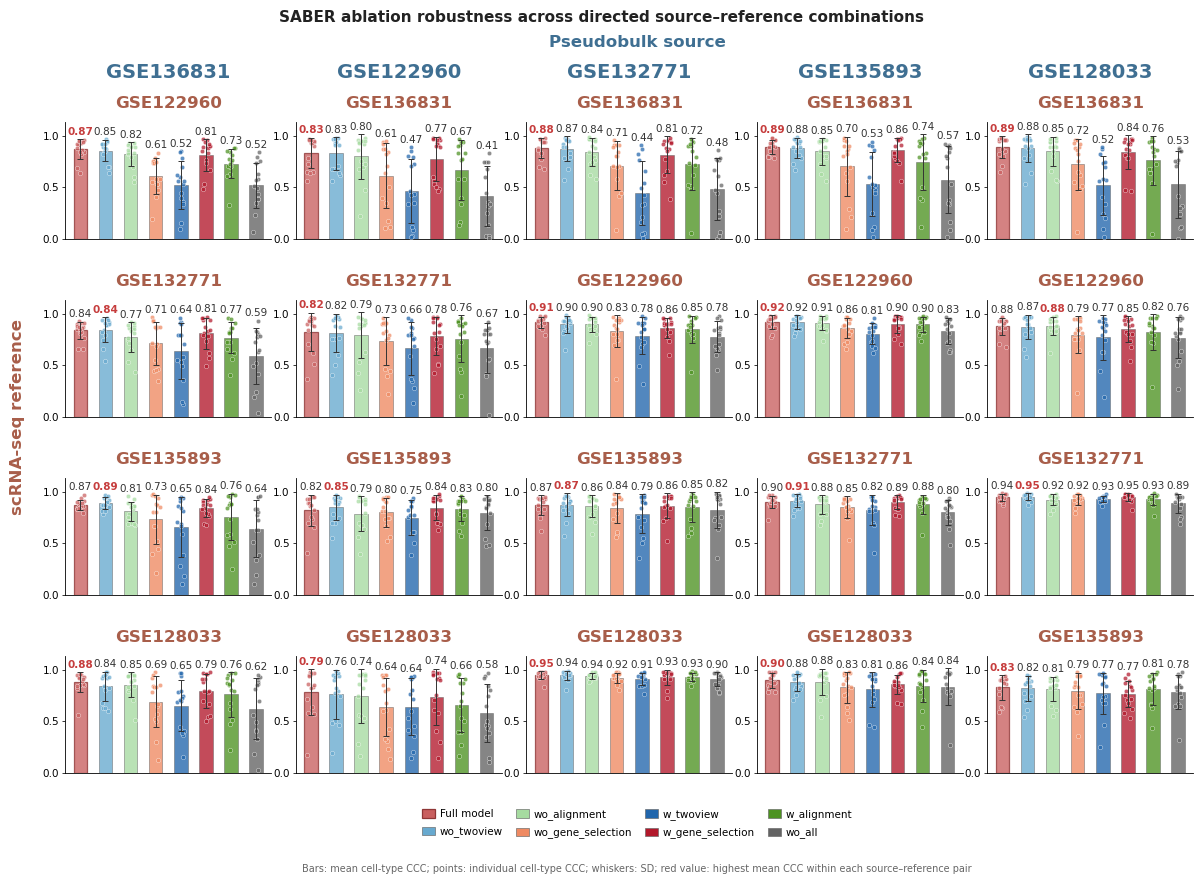

Saved: /Path/to/output/simulation_IPF/reference_robustness_ablation_compact_nested_matrix.pdf
Saved: /Path/to/output/simulation_IPF/reference_robustness_ablation_compact_nested_matrix.png


,Dataset,Reference,ReferenceDisplay,Pseudobulk,PseudobulkDisplay,Ablation,AblationDisplay,Method,MethodDisplay,MeanCCC,MedianCCC,SD,SEM,MinCCC,MaxCCC,NCellTypes
0,crossdataset_ref1_bulk2,IPFREF1,GSE136831,IPFREF2,GSE122960,SABER,Full model,SABER,Full model,0.830935,0.923724,0.148420,0.038322,0.561283,0.970198,15
1,crossdataset_ref1_bulk2,IPFREF1,GSE136831,IPFREF2,GSE122960,SABER_w_alignment,w_alignment,SABER_w_alignment,w_alignment,0.668186,0.775822,0.289233,0.074680,0.128753,0.965588,15
2,crossdataset_ref1_bulk2,IPFREF1,GSE136831,IPFREF2,GSE122960,SABER_w_gene_selection,w_gene_selection,SABER_w_gene_selection,w_gene_selection,0.772967,0.903176,0.215685,0.055690,0.458281,0.975176,15
3,crossdataset_ref1_bulk2,IPFREF1,GSE136831,IPFREF2,GSE122960,SABER_w_twoview,w_twoview,SABER_w_twoview,w_twoview,0.465581,0.430237,0.311636,0.080464,0.017430,0.884217,15
4,crossdataset_ref1_bulk2,IPFREF1,GSE136831,IPFREF2,GSE122960,SABER_wo_alignment,wo_alignment,SABER_wo_alignment,wo_alignment,0.796923,0.915862,0.215277,0.055584,0.223502,0.972962,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,crossdataset_ref5_bulk4,IPFREF5,GSE128033,IPFREF4,GSE135893,SABER_w_twoview,w_twoview,SABER_w_twoview,w_twoview,0.808440,0.888932,0.168124,0.043409,0.442934,0.960116,15
156,crossdataset_ref5_bulk4,IPFREF5,GSE128033,IPFREF4,GSE135893,SABER_wo_alignment,wo_alignment,SABER_wo_alignment,wo_alignment,0.882445,0.937110,0.124380,0.032115,0.537597,0.968366,15
157,crossdataset_ref5_bulk4,IPFREF5,GSE128033,IPFREF4,GSE135893,SABER_wo_all,wo_all,SABER_wo_all,wo_all,0.835273,0.856281,0.179574,0.046366,0.273384,0.979856,15
158,crossdataset_ref5_bulk4,IPFREF5,GSE128033,IPFREF4,GSE135893,SABER_wo_gene_selection,wo_gene_selection,SABER_wo_gene_selection,wo_gene_selection,0.826861,0.860280,0.150280,0.038802,0.510350,0.976583,15


In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.patches import Patch

# Configuration and output paths
REFERENCE_DATA_ROOT = "/Path/to/simulation_IPF/data"
MANIFEST_PATH = os.path.join(REFERENCE_DATA_ROOT, "crossdataset_manifest.csv")
REFERENCE_METHODS = [
    "SABER",
    "SABER_wo_twoview",
    "SABER_wo_alignment",
    "SABER_wo_gene_selection",
    "SABER_w_twoview",
    "SABER_w_gene_selection",
    "SABER_w_alignment",
    "SABER_wo_all",
]
REFERENCE_METHOD_DISPLAY = {
    "SABER": "Full model",
    "SABER_wo_twoview": "wo_twoview",
    "SABER_wo_alignment": "wo_alignment",
    "SABER_wo_gene_selection": "wo_gene_selection",
    "SABER_w_twoview": "w_twoview",
    "SABER_w_gene_selection": "w_gene_selection",
    "SABER_w_alignment": "w_alignment",
    "SABER_wo_all": "wo_all",
}
METHOD_PALETTE = {
    "Full model": "#C95F5F",
    "wo_alignment": "#A6DBA0",
    "wo_twoview": "#67A9CF",
    "wo_gene_selection": "#EF8A62",
    "w_gene_selection": "#B2182B",
    "w_twoview": "#2166AC",
    "w_alignment": "#4D9221",
    "wo_all": "#636363",
}
DATASET_DISPLAY = {
    "IPFREF1": "GSE136831",
    "IPFREF2": "GSE122960",
    "IPFREF3": "GSE132771",
    "IPFREF4": "GSE135893",
    "IPFREF5": "GSE128033",
}
OUTPUT_DIR = "/Path/to/output/simulation_IPF"
os.makedirs(OUTPUT_DIR, exist_ok=True)
OUTPUT_PDF = os.path.join(OUTPUT_DIR, "reference_robustness_ablation_compact_nested_matrix.pdf")
OUTPUT_PNG = os.path.join(OUTPUT_DIR, "reference_robustness_ablation_compact_nested_matrix.png")
OUTPUT_RAW_TABLE = os.path.join(
    OUTPUT_DIR, "reference_robustness_ablation_celltype_ccc_summary.csv"
)
OUTPUT_MEAN_TABLE = os.path.join(OUTPUT_DIR, "reference_robustness_ablation_mean_ccc_summary.csv")
SHOW_ERROR_BARS = True
SOURCE_LABEL_COLOR = "#3F6F92"
REFERENCE_LABEL_COLOR = "#A85E4A"
TICK_FONT_SIZE = 7.5
GLOBAL_AXIS_FONT_SIZE = 12.0
LEGEND_FONT_SIZE = 7.5
STRIP_JITTER = 0.16
AXIS_COLOR = "#000000"


# CCC statistics and input validation
def calculate_summary_ccc(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    valid = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[valid]
    y_pred = y_pred[valid]
    if len(y_true) < 2:
        return np.nan
    mean_true = np.mean(y_true)
    mean_pred = np.mean(y_pred)
    var_true = np.var(y_true, ddof=1)
    var_pred = np.var(y_pred, ddof=1)
    covariance = np.cov(y_true, y_pred, ddof=1)[0, 1]
    denominator = var_true + var_pred + (mean_true - mean_pred) ** 2
    if denominator == 0:
        return np.nan
    return 2 * covariance / denominator


def load_manifest():
    if not os.path.exists(MANIFEST_PATH):
        raise FileNotFoundError(f"Manifest not found: {MANIFEST_PATH}. Run /Path/to/simulation_IPF/generate.py first.")
    manifest = pd.read_csv(MANIFEST_PATH)
    required_columns = {"combo_id", "reference_id", "pseudobulk_source_id"}
    missing_columns = required_columns.difference(manifest.columns)
    if missing_columns:
        raise ValueError(f"Manifest missing columns: {sorted(missing_columns)}")
    manifest = manifest.drop_duplicates(
        subset=["combo_id", "reference_id", "pseudobulk_source_id"]
    ).reset_index(drop=True)
    return manifest


def collect_reference_celltype_ccc(manifest, methods):
    records = []
    for _, manifest_row in manifest.iterrows():
        combo_id = manifest_row["combo_id"]
        reference_id = manifest_row["reference_id"]
        pseudobulk_id = manifest_row["pseudobulk_source_id"]
        true_path = os.path.join(REFERENCE_DATA_ROOT, combo_id, "P.csv")
        if not os.path.exists(true_path):
            print(f"[Missing truth] {true_path}")
            continue
        true_df = pd.read_csv(true_path, index_col=0)
        for method in methods:
            prediction_path = os.path.join("/Path/to/simulation_IPF/results", combo_id, f"{method}.csv")
            if not os.path.exists(prediction_path):
                print(f"[Missing prediction] {prediction_path}")
                continue
            pred_df = pd.read_csv(prediction_path, index_col=0)
            common_samples = true_df.index.intersection(pred_df.index)
            common_celltypes = true_df.columns.intersection(pred_df.columns)
            if len(common_samples) == 0:
                print(f"[No common samples] {combo_id} | {method}")
                continue
            if len(common_celltypes) == 0:
                print(f"[No common cell types] {combo_id} | {method}")
                continue
            true_sub = true_df.loc[common_samples, common_celltypes].apply(
                pd.to_numeric, errors="coerce"
            )
            pred_sub = pred_df.loc[common_samples, common_celltypes].apply(
                pd.to_numeric, errors="coerce"
            )
            for celltype in common_celltypes:
                ccc_value = calculate_summary_ccc(
                    true_sub[celltype].values, pred_sub[celltype].values
                )
                if not np.isfinite(ccc_value):
                    continue
                method_display = REFERENCE_METHOD_DISPLAY[method]
                records.append(
                    {
                        "Dataset": combo_id,
                        "Reference": reference_id,
                        "ReferenceDisplay": DATASET_DISPLAY.get(reference_id, reference_id),
                        "Pseudobulk": pseudobulk_id,
                        "PseudobulkDisplay": DATASET_DISPLAY.get(pseudobulk_id, pseudobulk_id),
                        "Ablation": method,
                        "AblationDisplay": method_display,
                        "Method": method,
                        "MethodDisplay": method_display,
                        "CellType": celltype,
                        "CCC": float(ccc_value),
                    }
                )
    result = pd.DataFrame(records)
    if result.empty:
        raise ValueError("No valid CCC values were collected.")
    return result


def summarize_mean_ccc(raw_df):
    if raw_df.empty:
        return pd.DataFrame()
    summary_df = raw_df.groupby(
        [
            "Dataset",
            "Reference",
            "ReferenceDisplay",
            "Pseudobulk",
            "PseudobulkDisplay",
            "Ablation",
            "AblationDisplay",
            "Method",
            "MethodDisplay",
        ],
        as_index=False,
    ).agg(
        MeanCCC=("CCC", "mean"),
        MedianCCC=("CCC", "median"),
        SD=("CCC", "std"),
        SEM=("CCC", lambda x: x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0.0),
        MinCCC=("CCC", "min"),
        MaxCCC=("CCC", "max"),
        NCellTypes=("CCC", "count"),
    )
    summary_df["SD"] = summary_df["SD"].fillna(0)
    summary_df["SEM"] = summary_df["SEM"].fillna(0)
    return summary_df


# Publication plotting
def choose_publication_font():
    for font_name in ["Arial", "Helvetica", "Liberation Sans", "DejaVu Sans"]:
        try:
            fm.findfont(font_name, fallback_to_default=False)
            print(f"Using publication font: {font_name}")
            return font_name
        except ValueError:
            pass
    return "DejaVu Sans"


def set_publication_style():
    publication_font = choose_publication_font()
    plt.rcParams.update(
        {
            "font.family": "sans-serif",
            "font.sans-serif": [
                publication_font,
                "Arial",
                "Helvetica",
                "Liberation Sans",
                "DejaVu Sans",
            ],
            "font.size": 7.5,
            "ytick.labelsize": TICK_FONT_SIZE,
            "legend.fontsize": LEGEND_FONT_SIZE,
            "axes.linewidth": 0.6,
            "xtick.major.width": 0.55,
            "ytick.major.width": 0.55,
            "xtick.major.size": 2.5,
            "ytick.major.size": 2.5,
            "figure.facecolor": "white",
            "axes.facecolor": "white",
            "savefig.facecolor": "white",
            "savefig.edgecolor": "white",
            "savefig.dpi": 600,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
        }
    )


def determine_dataset_order(manifest):
    available_datasets = set(manifest["reference_id"]).union(set(manifest["pseudobulk_source_id"]))
    ordered_datasets = [
        dataset
        for dataset in ["IPFREF1", "IPFREF2", "IPFREF3", "IPFREF4", "IPFREF5"]
        if dataset in available_datasets
    ]
    extra_datasets = sorted(available_datasets.difference(ordered_datasets))
    ordered_datasets.extend(extra_datasets)
    return ordered_datasets


def validate_offdiagonal_design(summary_df, dataset_order):
    available_pairs = set(
        summary_df[["Pseudobulk", "Reference"]].drop_duplicates().itertuples(index=False, name=None)
    )
    missing_pairs = []
    for pseudobulk in dataset_order:
        for reference in dataset_order:
            if pseudobulk == reference:
                continue
            if (pseudobulk, reference) not in available_pairs:
                missing_pairs.append((pseudobulk, reference))
    if missing_pairs:
        missing_text = [f"{pseudobulk} -> {reference}" for pseudobulk, reference in missing_pairs]
        raise ValueError(
            f"The packed layout requires every off-diagonal pseudobulk-reference combination. Missing combinations: {missing_text}"
        )


def determine_y_limits(summary_df, raw_df):
    summary_mean = pd.to_numeric(summary_df["MeanCCC"], errors="coerce")
    summary_sd = pd.to_numeric(summary_df["SD"], errors="coerce").fillna(0)
    raw_ccc = pd.to_numeric(raw_df["CCC"], errors="coerce")
    minimum_value = np.nanmin([np.nanmin(summary_mean - summary_sd), np.nanmin(raw_ccc)])
    if minimum_value >= 0:
        y_min = 0.0
    else:
        y_min = np.floor(minimum_value * 10) / 10
        y_min = max(-1.0, y_min)
    upper_data_value = np.nanmax([1.0, np.nanmax(raw_ccc), np.nanmax(summary_mean + summary_sd)])
    basic_span = max(1.0 - y_min, 1.0)
    y_max = upper_data_value + 0.12 * basic_span
    return (y_min, y_max)


def draw_combination_panel(
    ax, summary_df, raw_df, pseudobulk, reference, method_order, x_positions, y_limits
):
    panel_summary = summary_df[
        (summary_df["Pseudobulk"] == pseudobulk) & (summary_df["Reference"] == reference)
    ].copy()
    panel_raw = raw_df[
        (raw_df["Pseudobulk"] == pseudobulk) & (raw_df["Reference"] == reference)
    ].copy()
    panel_summary = panel_summary.set_index("Method").reindex(method_order)
    mean_values = pd.to_numeric(panel_summary["MeanCCC"], errors="coerce").to_numpy(dtype=float)
    sd_values = pd.to_numeric(panel_summary["SD"], errors="coerce").fillna(0).to_numpy(dtype=float)
    valid = np.isfinite(mean_values)
    if not np.any(valid):
        raise ValueError(f"No valid ablation values for {pseudobulk} -> {reference}")
    best_index = int(np.nanargmax(mean_values))
    method_point_values = {}
    for method in method_order:
        method_point_values[method] = (
            panel_raw.loc[panel_raw["Method"] == method, "CCC"]
            .pipe(pd.to_numeric, errors="coerce")
            .dropna()
            .to_numpy(dtype=float)
        )
    y_min, y_max = y_limits
    basic_span = max(1.0 - y_min, 1.0)
    for method_index, method in enumerate(method_order):
        mean_value = mean_values[method_index]
        if not np.isfinite(mean_value):
            continue
        method_display = REFERENCE_METHOD_DISPLAY[method]
        bar_color = METHOD_PALETTE[method_display]
        ax.bar(
            x_positions[method_index],
            mean_value,
            width=0.54,
            color=bar_color,
            edgecolor="#8F3636" if method == "SABER" else "#666666",
            linewidth=0.9 if method == "SABER" else 0.45,
            alpha=0.78,
            zorder=2,
        )
    for method_index, method in enumerate(method_order):
        point_values = method_point_values[method]
        if len(point_values) == 0:
            continue
        method_display = REFERENCE_METHOD_DISPLAY[method]
        point_color = METHOD_PALETTE[method_display]
        rng = np.random.default_rng(20260812 + method_index)
        if len(point_values) == 1:
            jitter = np.array([0.0])
        else:
            jitter = rng.uniform(-STRIP_JITTER, STRIP_JITTER, size=len(point_values))
        ax.scatter(
            x_positions[method_index] + jitter,
            point_values,
            s=10.0,
            color=point_color,
            alpha=0.72,
            edgecolor="white",
            linewidth=0.35,
            zorder=4,
            clip_on=True,
        )
    if SHOW_ERROR_BARS:
        for method_index, method in enumerate(method_order):
            mean_value = mean_values[method_index]
            if not np.isfinite(mean_value):
                continue
            ax.errorbar(
                x_positions[method_index],
                mean_value,
                yerr=sd_values[method_index],
                fmt="none",
                ecolor="#333333",
                elinewidth=0.7,
                capsize=2.0,
                capthick=0.7,
                zorder=6,
                clip_on=True,
            )
    for method_index, method in enumerate(method_order):
        mean_value = mean_values[method_index]
        if not np.isfinite(mean_value):
            continue
        point_values = method_point_values[method]
        top_candidates = [max(0.0, mean_value)]
        visible_points = point_values[(point_values >= y_min) & (point_values <= y_max)]
        if len(visible_points) > 0:
            top_candidates.append(np.nanmax(visible_points))
        if SHOW_ERROR_BARS:
            top_candidates.append(mean_value + sd_values[method_index])
        element_top = np.nanmax(top_candidates)
        label_y = element_top + 0.025 * basic_span
        label_y = min(label_y, y_max - 0.015 * basic_span)
        is_best = method_index == best_index
        label_color = "#C63D3D" if is_best else "#333333"
        label_weight = "bold" if is_best else "normal"
        ax.text(
            x_positions[method_index],
            label_y,
            f"{mean_value:.2f}",
            ha="center",
            va="bottom",
            fontsize=7.5,
            color=label_color,
            fontweight=label_weight,
            zorder=8,
            clip_on=False,
        )


def style_numeric_panel(ax):
    ax.grid(False)
    ax.set_xticks([])
    ax.tick_params(axis="x", bottom=False, top=False, labelbottom=False)
    ax.tick_params(
        axis="y",
        left=True,
        right=False,
        labelleft=True,
        direction="out",
        length=2.5,
        width=0.55,
        pad=2.0,
        colors=AXIS_COLOR,
        labelcolor=AXIS_COLOR,
        labelsize=TICK_FONT_SIZE,
    )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(True)
    ax.spines["bottom"].set_linewidth(0.6)
    ax.spines["bottom"].set_color(AXIS_COLOR)
    ax.spines["left"].set_visible(True)
    ax.spines["left"].set_linewidth(0.6)
    ax.spines["left"].set_color(AXIS_COLOR)


def plot_nested_matrix(summary_df, raw_df, manifest):
    set_publication_style()
    dataset_order = determine_dataset_order(manifest)
    validate_offdiagonal_design(summary_df=summary_df, dataset_order=dataset_order)
    method_order = [
        method for method in REFERENCE_METHODS if method in summary_df["Method"].unique()
    ]
    x_positions = np.arange(len(method_order), dtype=float)
    n_sources = len(dataset_order)
    n_reference_rows = n_sources - 1
    y_min, y_max = determine_y_limits(summary_df=summary_df, raw_df=raw_df)
    if y_min >= 0:
        y_ticks = [0.0, 0.5, 1.0]
    else:
        y_ticks = sorted(set([y_min, 0.0, 0.5, 1.0]))
    fig, axes = plt.subplots(
        nrows=n_reference_rows,
        ncols=n_sources,
        figsize=(11.96, 8.8),
        sharex=False,
        sharey=False,
        squeeze=False,
    )
    for source_col, pseudobulk in enumerate(dataset_order):
        references_for_source = [
            reference for reference in dataset_order if reference != pseudobulk
        ]
        for reference_row, reference in enumerate(references_for_source):
            ax = axes[reference_row, source_col]
            ax.set_ylim(y_min, y_max)
            x_margin = 0.6
            ax.set_xlim(x_positions[0] - x_margin, x_positions[-1] + x_margin)
            ax.set_yticks(y_ticks)
            ax.set_title(
                DATASET_DISPLAY.get(reference, reference),
                fontsize=12.0,
                fontweight="bold",
                pad=10,
                color=REFERENCE_LABEL_COLOR,
            )
            if reference_row == 0:
                ax.text(
                    0.5,
                    1.34,
                    DATASET_DISPLAY.get(pseudobulk, pseudobulk),
                    transform=ax.transAxes,
                    ha="center",
                    va="bottom",
                    fontsize=14.0,
                    fontweight="bold",
                    color=SOURCE_LABEL_COLOR,
                    clip_on=False,
                )
            draw_combination_panel(
                ax=ax,
                summary_df=summary_df,
                raw_df=raw_df,
                pseudobulk=pseudobulk,
                reference=reference,
                method_order=method_order,
                x_positions=x_positions,
                y_limits=(y_min, y_max),
            )
            style_numeric_panel(ax=ax)
    fig.suptitle(
        "SABER ablation robustness across directed source–reference combinations",
        fontsize=11.0,
        fontweight="bold",
        y=0.992,
        color="#222222",
    )
    fig.text(
        0.53,
        0.955,
        "Pseudobulk source",
        ha="center",
        va="center",
        fontsize=GLOBAL_AXIS_FONT_SIZE,
        fontweight="bold",
        color=SOURCE_LABEL_COLOR,
    )
    fig.text(
        0.012,
        0.53,
        "scRNA-seq reference",
        ha="center",
        va="center",
        rotation=90,
        fontsize=GLOBAL_AXIS_FONT_SIZE,
        fontweight="bold",
        color=REFERENCE_LABEL_COLOR,
    )
    legend_handles = [
        Patch(
            facecolor=METHOD_PALETTE[REFERENCE_METHOD_DISPLAY[method]],
            edgecolor="#8F3636" if method == "SABER" else "#666666",
            linewidth=0.9 if method == "SABER" else 0.45,
            label=REFERENCE_METHOD_DISPLAY[method],
        )
        for method in method_order
    ]
    fig.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.53, 0.04),
        ncol=4,
        frameon=False,
        fontsize=LEGEND_FONT_SIZE,
        columnspacing=1.25,
        handlelength=1.25,
        handleheight=0.85,
        handletextpad=0.45,
        labelspacing=0.7,
    )
    fig.text(
        0.53,
        0.01,
        "Bars: mean cell-type CCC; points: individual cell-type CCC; whiskers: SD; red value: highest mean CCC within each source–reference pair",
        ha="center",
        va="bottom",
        fontsize=7.0,
        color="#666666",
    )
    fig.subplots_adjust(left=0.052, right=0.995, bottom=0.125, top=0.865, wspace=0.12, hspace=0.52)
    fig.savefig(OUTPUT_PDF, bbox_inches="tight", dpi=600)
    fig.savefig(OUTPUT_PNG, bbox_inches="tight", dpi=600)
    plt.show()
    print(f"Saved: {OUTPUT_PDF}")
    print(f"Saved: {OUTPUT_PNG}")
    return fig


# Run analysis and save outputs
manifest_df = load_manifest()
ablation_celltype_summary_df = collect_reference_celltype_ccc(
    manifest=manifest_df, methods=REFERENCE_METHODS
)
ablation_mean_summary_df = summarize_mean_ccc(ablation_celltype_summary_df)
ablation_celltype_summary_df.to_csv(OUTPUT_RAW_TABLE, index=False)
ablation_mean_summary_df.to_csv(OUTPUT_MEAN_TABLE, index=False)
print(f"Saved table: {OUTPUT_RAW_TABLE}")
print(f"Saved table: {OUTPUT_MEAN_TABLE}")
print(
    "Directed combinations:",
    ablation_mean_summary_df[["Pseudobulk", "Reference"]].drop_duplicates().shape[0],
)
print("Available ablations:", ablation_mean_summary_df["Method"].nunique())
plot_nested_matrix(
    summary_df=ablation_mean_summary_df, raw_df=ablation_celltype_summary_df, manifest=manifest_df
)
ablation_mean_summary_df
